# Sparse Dictionary Learning for Image Denoising

## Unsupervised Discovery of Visual Building Blocks

This project trains an unsupervised dictionary-learning model on small patches
extracted from natural images.

The model learns reusable visual atoms such as edges, gradients, corners, and
textures. A noisy image patch is then reconstructed as a sparse combination of
only a few atoms.

The project includes:

1. Patch extraction from unlabeled training images
2. Sparse dictionary learning
3. Visualization of learned atoms
4. Validation of the sparse-coding level
5. Comparison with Gaussian filtering
6. Evaluation using PSNR, SSIM, and MAE
7. Robustness testing across different noise levels
8. Spatial error analysis

The model never receives image categories or clean target patches during
training. Clean validation and test images are used only to measure restoration
quality.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.ndimage import uniform_filter
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.feature_extraction.image import (
    extract_patches_2d, reconstruct_from_patches_2d
)
from skimage import color, data, filters, metrics, transform

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
IMAGE_SIZE = (192, 192)
PATCH_SIZE = (8, 8)
NOISE_SIGMA = 0.12

## Training, validation, and test separation

Four natural images are used only for unsupervised dictionary learning.

A separate coins image is used to select reconstruction settings. The camera
and moon images remain untouched until final evaluation.

This separation tests whether the learned visual atoms can generalize to new
image content rather than merely reconstructing the training images.

In [3]:
def prepare_image(image):
    if image.ndim == 3:
        image = color.rgb2gray(image)
    image = transform.resize(image, IMAGE_SIZE, anti_aliasing=True)
    return image.astype(np.float32)

training_images = {
    "Astronaut": prepare_image(data.astronaut()),
    "Coffee": prepare_image(data.coffee()),
    "Chelsea": prepare_image(data.chelsea()),
    "Rocket": prepare_image(data.rocket())
}

validation_image = prepare_image(data.coins())

test_images = {
    "Camera": prepare_image(data.camera()),
    "Moon": prepare_image(data.moon())
}

print(f"Training images: {len(training_images)}")
print(f"Validation images: 1")
print(f"Test images: {len(test_images)}")
print(f"Processed shape: {IMAGE_SIZE}")

Training images: 4
Validation images: 1
Test images: 2
Processed shape: (192, 192)


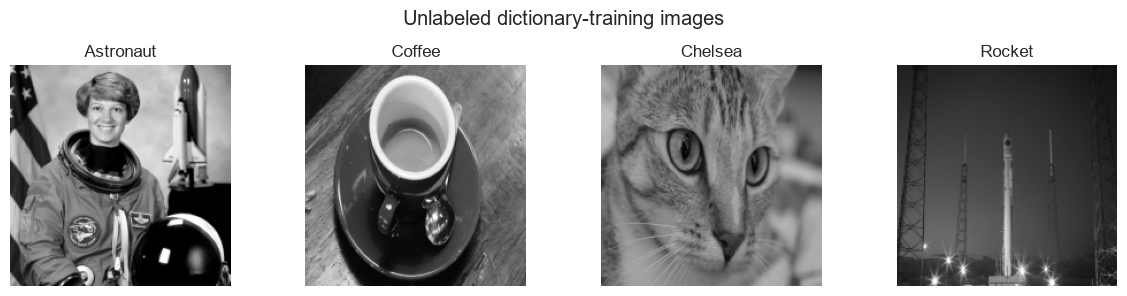

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for ax, (name, image) in zip(axes, training_images.items()):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Unlabeled dictionary-training images")
plt.tight_layout()
plt.show()

## Image preparation observations

> **Replace after running**
>
> - The dictionary was trained using **[number] natural images**, while
>   validation and testing used completely separate images.
> - Every image was converted to grayscale and resized to **[dimensions]**.
> - The training set contained a mixture of **[briefly describe visible
>   structures and textures]**.
> - This visual diversity should allow the dictionary to learn components that
>   are more general than those from a single image.

In [5]:
patch_blocks = []

for seed_offset, image in enumerate(training_images.values()):
    patches = extract_patches_2d(
        image, PATCH_SIZE, max_patches=1500,
        random_state=RANDOM_STATE + seed_offset
    )
    patches = patches.reshape(len(patches), -1)
    patches -= patches.mean(axis=1, keepdims=True)
    patch_blocks.append(patches)

training_patches = np.vstack(patch_blocks)
initial_patch_count = len(training_patches)

patch_std = training_patches.std(axis=1)
training_patches = training_patches[patch_std > 0.02]

print(f"Initially extracted patches: {initial_patch_count:,}")
print(f"Informative patches retained: {len(training_patches):,}")
print(f"Patch features: {training_patches.shape[1]}")
print(f"Removed low-variation patches: {initial_patch_count - len(training_patches):,}")

Initially extracted patches: 6,000
Informative patches retained: 4,260
Patch features: 64
Removed low-variation patches: 1,740


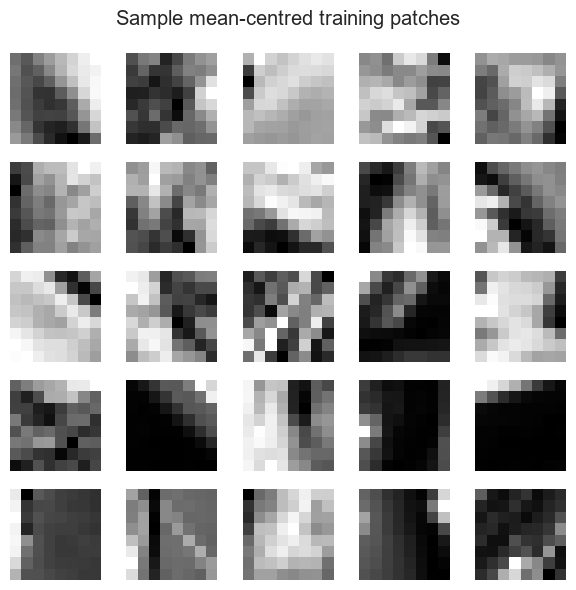

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
sample_indices = rng.choice(len(training_patches), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(6, 6))

for ax, index in zip(axes.ravel(), sample_indices):
    ax.imshow(training_patches[index].reshape(PATCH_SIZE), cmap="gray")
    ax.axis("off")

plt.suptitle("Sample mean-centred training patches")
plt.tight_layout()
plt.show()

## Image preparation observations

- The dictionary was trained using **4 natural images**, while one validation
  image and two test images were kept completely separate.
- Every image was converted to grayscale and resized to **192 × 192 pixels**.
- The training images contained faces, curved object boundaries, fur, wood
  texture, smooth backgrounds, shadows, fine lines, and high-contrast
  structures from the astronaut, coffee, cat, and rocket scenes.
- This visual diversity allowed the dictionary to learn local structures that
  were not specific to only one image.
- The validation and test separation also tested whether the learned atoms
  could generalize to the unseen Coins, Camera, and Moon images.

## Patch extraction findings

- A total of **6,000 patches** were initially extracted, with 1,500 sampled
  from each training image.
- After removing **1,740 nearly uniform patches**, **4,260 informative patches**
  remained.
- Each 8 × 8 patch was represented by **64 pixel features**.
- Subtracting each patch's mean allowed the model to focus on local contrast
  and structure rather than absolute brightness.
- The retained patches contained vertical, horizontal, and diagonal edges,
  smooth gradients, curved boundaries, corners, and irregular textures.
- Removing low-variation patches prevented the dictionary from spending too
  many atoms on almost featureless image regions.

## Sparse dictionary learning

The dictionary contains 64 atoms. During reconstruction, Orthogonal Matching
Pursuit limits each patch to a small number of active atoms.

In [7]:
dictionary = MiniBatchDictionaryLearning(
    n_components=64, alpha=1, max_iter=200,
    batch_size=256, fit_algorithm="lars",
    transform_algorithm="omp", random_state=RANDOM_STATE,
    n_jobs=-1, max_no_improvement=20
)

dictionary.fit(training_patches)

print(f"Learned atoms: {dictionary.components_.shape[0]}")
print(f"Pixels per atom: {dictionary.components_.shape[1]}")
print(f"Training iterations: {dictionary.n_iter_}")

Learned atoms: 64
Pixels per atom: 64
Training iterations: 6.0


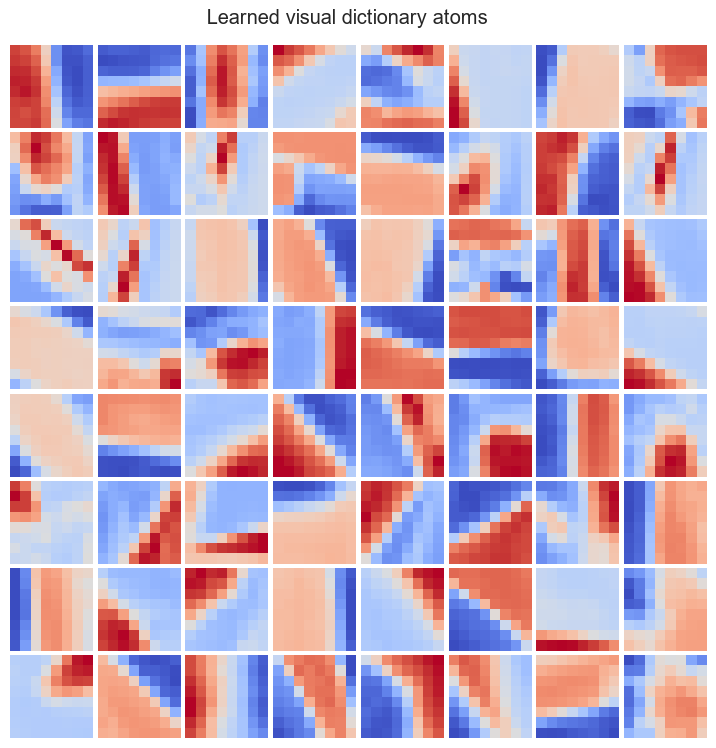

In [8]:
fig, axes = plt.subplots(8, 8, figsize=(9, 9))

for ax, atom in zip(axes.ravel(), dictionary.components_):
    atom = atom.reshape(PATCH_SIZE)
    scale = max(abs(atom.min()), abs(atom.max()))
    ax.imshow(atom, cmap="coolwarm", vmin=-scale, vmax=scale)
    ax.axis("off")

plt.suptitle("Learned visual dictionary atoms", y=0.92)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

## Dictionary learning observations

- The model learned **64 visual atoms**, each containing 64 pixel values, after
  **6 training iterations**.
- Training ended substantially before the maximum of 200 iterations, indicating
  that the mini-batch optimization satisfied its convergence or early-stopping
  condition quickly.
- Many atoms resembled horizontal, vertical, and diagonal edges at different
  locations and orientations.
- Other atoms captured smooth gradients, curved boundaries, corner-like
  structures, narrow bands, and local transitions between dark and bright
  regions.
- The red and blue colours represent positive and negative atom values rather
  than real image colours.
- Several atoms appeared visually similar because edges at slightly different
  positions and orientations require separate components. Some irregular atoms
  were less interpretable and may represent textures or mixtures of several
  local patterns.
- These components emerged without image labels or manually specified edge
  filters.

In [9]:
def add_gaussian_noise(image, sigma, seed):
    rng = np.random.default_rng(seed)
    noisy = image + rng.normal(0, sigma, image.shape)
    return np.clip(noisy, 0, 1).astype(np.float32)

def dictionary_denoise(noisy_image, nonzero_atoms):
    patches = extract_patches_2d(noisy_image, PATCH_SIZE)
    flat_patches = patches.reshape(len(patches), -1)
    patch_means = flat_patches.mean(axis=1, keepdims=True)
    centred_patches = flat_patches - patch_means

    dictionary.set_params(
        transform_algorithm="omp",
        transform_n_nonzero_coefs=nonzero_atoms
    )
    codes = dictionary.transform(centred_patches)
    reconstructed = codes @ dictionary.components_ + patch_means
    reconstructed = reconstructed.reshape(-1, *PATCH_SIZE)

    image = reconstruct_from_patches_2d(reconstructed, noisy_image.shape)
    return np.clip(image, 0, 1), codes

def image_scores(clean, restored):
    return {
        "PSNR": metrics.peak_signal_noise_ratio(clean, restored, data_range=1),
        "SSIM": metrics.structural_similarity(clean, restored, data_range=1),
        "MAE": np.mean(np.abs(clean - restored))
    }

## Validation strategy

Sparse reconstruction requires a decision about how many atoms may represent
each patch.

Too few atoms may remove genuine image structure. Too many may reconstruct the
noise itself.

The number of active atoms is selected using the validation image. Gaussian
filter strength is tuned separately to provide a fair conventional baseline.
The test images remain unused during this process.

In [10]:
validation_noisy = add_gaussian_noise(
    validation_image, NOISE_SIGMA, seed=100
)

dictionary_validation = []

for nonzero_atoms in [2, 4, 6, 8]:
    restored, _ = dictionary_denoise(validation_noisy, nonzero_atoms)
    dictionary_validation.append({
        "method": "Dictionary",
        "parameter": nonzero_atoms,
        **image_scores(validation_image, restored)
    })

gaussian_validation = []

for gaussian_sigma in [0.5, 0.8, 1.1, 1.4]:
    restored = filters.gaussian(
        validation_noisy, sigma=gaussian_sigma, preserve_range=True
    )
    gaussian_validation.append({
        "method": "Gaussian",
        "parameter": gaussian_sigma,
        **image_scores(validation_image, restored)
    })

validation_results = pd.DataFrame(
    dictionary_validation + gaussian_validation
)

best_dictionary_row = validation_results[
    validation_results["method"] == "Dictionary"
].sort_values("PSNR", ascending=False).iloc[0]

best_gaussian_row = validation_results[
    validation_results["method"] == "Gaussian"
].sort_values("PSNR", ascending=False).iloc[0]

BEST_ATOMS = int(best_dictionary_row["parameter"])
BEST_GAUSSIAN_SIGMA = float(best_gaussian_row["parameter"])

display(validation_results.round(4))
print(f"Selected active atoms: {BEST_ATOMS}")
print(f"Selected Gaussian sigma: {BEST_GAUSSIAN_SIGMA}")

,method,parameter,PSNR,SSIM,MAE
0,Dictionary,2.0,25.8168,0.7128,0.0373
1,Dictionary,4.0,25.5342,0.6718,0.0404
2,Dictionary,6.0,25.1017,0.6410,0.0434
3,Dictionary,8.0,24.6464,0.6168,0.0461
4,Gaussian,0.5,22.2928,0.5203,0.0614
5,Gaussian,0.8,25.1127,0.6532,0.0425
6,Gaussian,1.1,24.8700,0.6891,0.0408
7,Gaussian,1.4,24.1380,0.6897,0.0425


Selected active atoms: 2
Selected Gaussian sigma: 0.8


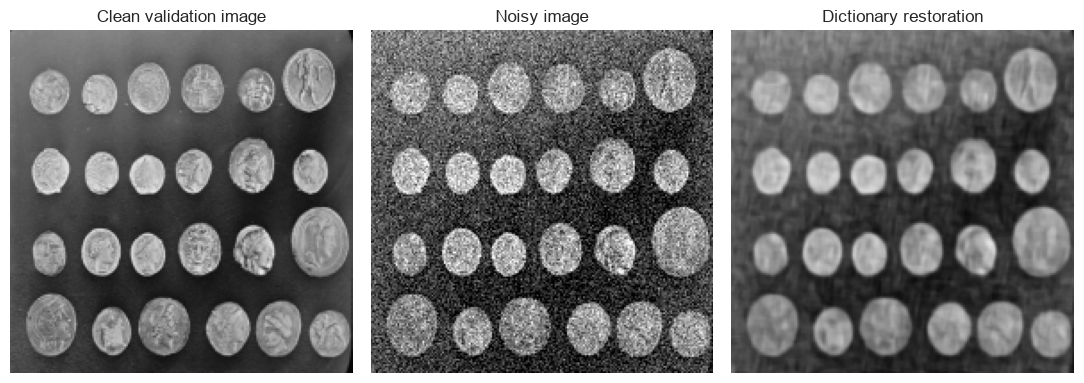

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))

validation_dictionary, _ = dictionary_denoise(
    validation_noisy, BEST_ATOMS
)
validation_gaussian = filters.gaussian(
    validation_noisy, sigma=BEST_GAUSSIAN_SIGMA,
    preserve_range=True
)

for ax, title, image in zip(
    axes,
    ["Clean validation image", "Noisy image", "Dictionary restoration"],
    [validation_image, validation_noisy, validation_dictionary]
):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Validation findings

- The best sparse reconstruction used **2 active atoms per patch**.
- This setting achieved validation PSNR = **25.8168 dB**, SSIM = **0.7128**,
  and MAE = **0.0373**.
- Two atoms was the smallest tested setting, so the experiment does not show
  what would happen with only one active atom.
- Increasing the limit to 4, 6, and 8 atoms progressively reduced PSNR and
  SSIM while increasing MAE.
- This indicates that the additional atoms began reconstructing random noise
  rather than useful image structure. Strong sparsity acted as a denoising
  constraint.
- The selected Gaussian-filter standard deviation was **0.8**, producing
  validation PSNR = **25.1127 dB**, SSIM = **0.6532**, and MAE = **0.0425**.
- Although sigma 1.4 achieved a slightly higher Gaussian SSIM, sigma 0.8 was
  correctly selected because PSNR was the predefined selection criterion.
- All settings were fixed before evaluating the Camera and Moon images.

In [12]:
test_rows = []
restorations = {}

for image_number, (name, clean) in enumerate(test_images.items()):
    noisy = add_gaussian_noise(clean, NOISE_SIGMA, seed=200 + image_number)
    gaussian = filters.gaussian(
        noisy, sigma=BEST_GAUSSIAN_SIGMA, preserve_range=True
    )
    sparse, codes = dictionary_denoise(noisy, BEST_ATOMS)

    restorations[name] = {
        "Clean": clean,
        "Noisy": noisy,
        "Gaussian": gaussian,
        "Dictionary": sparse,
        "Codes": codes
    }

    for method, restored in {
        "Noisy": noisy,
        "Gaussian": gaussian,
        "Dictionary": sparse
    }.items():
        test_rows.append({
            "image": name,
            "method": method,
            **image_scores(clean, restored)
        })

test_results = pd.DataFrame(test_rows)
display(test_results.round(4))

,image,method,PSNR,SSIM,MAE
0,Camera,Noisy,18.9517,0.2799,0.0901
1,Camera,Gaussian,25.6016,0.5537,0.0398
2,Camera,Dictionary,26.2746,0.6344,0.0350
3,Moon,Noisy,18.4457,0.1092,0.0953
4,Moon,Gaussian,27.1863,0.4373,0.0347
5,Moon,Dictionary,29.3894,0.5864,0.0268


,PSNR,SSIM,MAE
method,,,
Dictionary,27.8320,0.6104,0.0309
Gaussian,26.3940,0.4955,0.0373
Noisy,18.6987,0.1946,0.0927


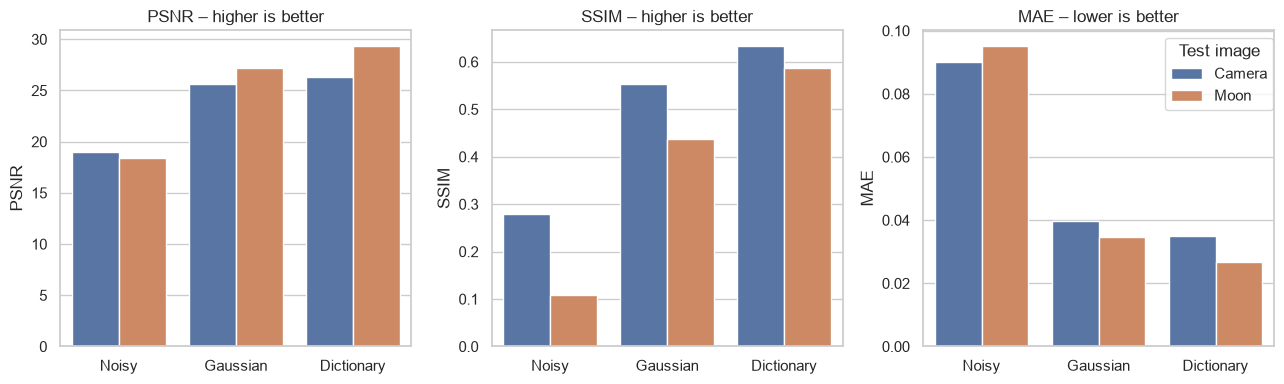

In [13]:
summary = test_results.groupby("method")[["PSNR", "SSIM", "MAE"]].mean()
summary = summary.sort_values("PSNR", ascending=False)

display(summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sns.barplot(data=test_results, x="method", y="PSNR", hue="image", ax=axes[0])
axes[0].set_title("PSNR – higher is better")

sns.barplot(data=test_results, x="method", y="SSIM", hue="image", ax=axes[1])
axes[1].set_title("SSIM – higher is better")

sns.barplot(data=test_results, x="method", y="MAE", hue="image", ax=axes[2])
axes[2].set_title("MAE – lower is better")

for ax in axes:
    ax.set_xlabel("")
    if ax.legend_:
        ax.legend_.remove()

axes[-1].legend(title="Test image", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

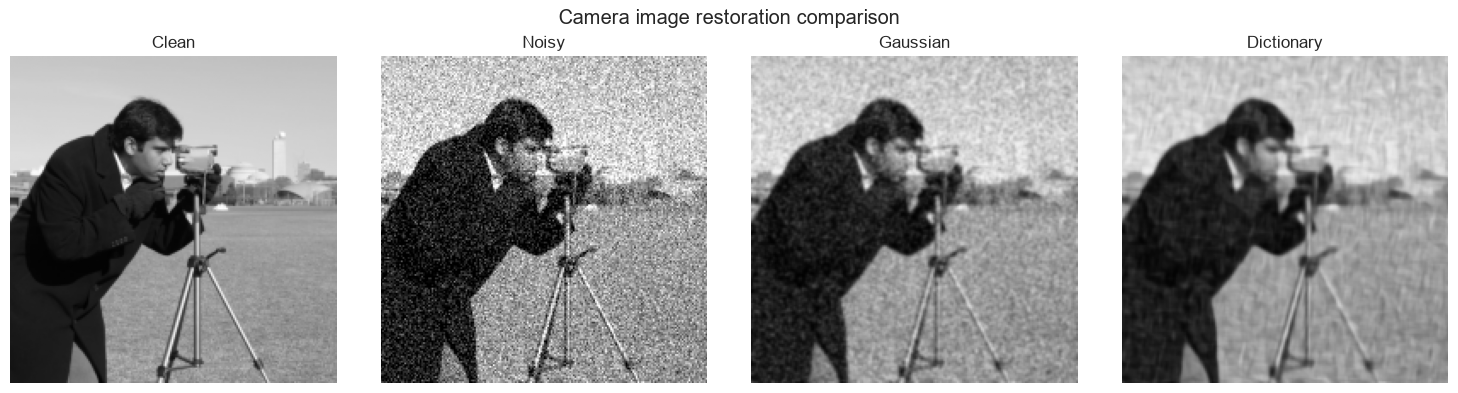

In [14]:
camera_results = restorations["Camera"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, name in zip(
    axes, ["Clean", "Noisy", "Gaussian", "Dictionary"]
):
    ax.imshow(camera_results[name], cmap="gray", vmin=0, vmax=1)
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Camera image restoration comparison")
plt.tight_layout()
plt.show()

## Test set findings

- The noisy test images had mean PSNR = **18.6987 dB**, SSIM = **0.1946**,
  and MAE = **0.0927**.
- Gaussian filtering improved the mean results to PSNR = **26.3940 dB**,
  SSIM = **0.4955**, and MAE = **0.0373**.
- Dictionary learning achieved the best mean results: PSNR =
  **27.8320 dB**, SSIM = **0.6104**, and MAE = **0.0309**.
- Relative to Gaussian filtering, dictionary learning improved mean PSNR by
  **1.4380 dB**, improved SSIM by **0.1149**, and reduced MAE by approximately
  **17.2%**.
- Dictionary learning outperformed Gaussian filtering on all three metrics for
  both test images.
- On Camera, dictionary learning achieved PSNR = **26.2746 dB** and SSIM =
  **0.6344**, compared with 25.6016 dB and 0.5537 for Gaussian filtering.
- On Moon, its advantage was larger: PSNR increased from **27.1863 to
  29.3894 dB**, while SSIM increased from **0.4373 to 0.5864**.
- Visually, both methods removed substantial noise, but Gaussian filtering
  blurred boundaries more uniformly. Dictionary reconstruction preserved
  major edges and shapes more effectively, although it also produced some
  patch-like smoothing and lost fine texture.

In [15]:
camera_codes = camera_results["Codes"]
active_counts = np.count_nonzero(np.abs(camera_codes) > 1e-10, axis=1)
atom_usage = np.mean(np.abs(camera_codes) > 1e-10, axis=0)

diagnostic_patches = extract_patches_2d(
    camera_results["Noisy"], PATCH_SIZE,
    max_patches=4000, random_state=RANDOM_STATE
)
diagnostic_flat = diagnostic_patches.reshape(len(diagnostic_patches), -1)
diagnostic_flat -= diagnostic_flat.mean(axis=1, keepdims=True)

dictionary.set_params(transform_n_nonzero_coefs=BEST_ATOMS)
diagnostic_codes = dictionary.transform(diagnostic_flat)
diagnostic_reconstruction = diagnostic_codes @ dictionary.components_
patch_mse = np.mean((diagnostic_flat - diagnostic_reconstruction) ** 2)

print(f"Mean active atoms per patch: {active_counts.mean():.3f}")
print(f"Median active atoms per patch: {np.median(active_counts):.1f}")
print(f"Diagnostic patch reconstruction MSE: {patch_mse:.6f}")

Mean active atoms per patch: 2.000
Median active atoms per patch: 2.0
Diagnostic patch reconstruction MSE: 0.013030


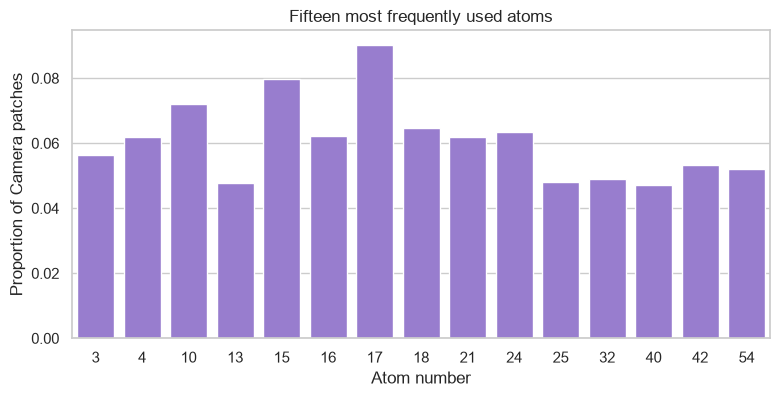

,atom,usage_rate
17,17,0.0902
15,15,0.0797
10,10,0.0721
18,18,0.0647
24,24,0.0634
16,16,0.0621
21,21,0.0620
4,4,0.0618
3,3,0.0563
42,42,0.0533


In [16]:
usage = pd.DataFrame({
    "atom": np.arange(len(atom_usage)),
    "usage_rate": atom_usage
}).sort_values("usage_rate", ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(data=usage.head(15), x="atom", y="usage_rate", color="mediumpurple")
plt.title("Fifteen most frequently used atoms")
plt.xlabel("Atom number")
plt.ylabel("Proportion of Camera patches")
plt.show()

display(usage.head(15).round(4))

## Sparse representation 

- Each Camera patch used exactly **2 active atoms on average and at the
  median**, from a dictionary containing 64 atoms.
- Therefore, each local patch used only **3.125% of the available atoms**.
- The diagnostic patch-reconstruction MSE was **0.013030**.
- Atom **17** was used most frequently, appearing in approximately **9.02%**
  of Camera patches.
- No single atom dominated the reconstruction. Even the most frequently used
  atom appeared in fewer than one-tenth of the patches.
- Atom usage was therefore fairly distributed across the dictionary, although
  some atoms were consistently preferred.
- This supports the central sparse-representation assumption: different local
  regions used different small subsets of a shared visual vocabulary.

In [17]:
robustness_rows = []
camera_clean = test_images["Camera"]

for level_number, noise_level in enumerate([0.05, 0.10, 0.15, 0.20]):
    noisy = add_gaussian_noise(
        camera_clean, noise_level, seed=500 + level_number
    )
    gaussian = filters.gaussian(
        noisy, sigma=BEST_GAUSSIAN_SIGMA, preserve_range=True
    )
    sparse, _ = dictionary_denoise(noisy, BEST_ATOMS)

    for method, restored in {
        "Noisy": noisy,
        "Gaussian": gaussian,
        "Dictionary": sparse
    }.items():
        robustness_rows.append({
            "noise_sigma": noise_level,
            "method": method,
            **image_scores(camera_clean, restored)
        })

robustness_results = pd.DataFrame(robustness_rows)
display(robustness_results.round(4))

,noise_sigma,method,PSNR,SSIM,MAE
0,0.05,Noisy,26.1720,0.5365,0.0392
1,0.05,Gaussian,28.9570,0.7982,0.0233
2,0.05,Dictionary,28.3860,0.8183,0.0231
3,0.10,Noisy,20.3995,0.3223,0.0763
4,0.10,Gaussian,26.5678,0.6160,0.0350
5,0.10,Dictionary,26.9721,0.6889,0.0314
6,0.15,Noisy,17.1568,0.2264,0.1106
7,0.15,Gaussian,24.3425,0.4819,0.0469
8,0.15,Dictionary,25.3384,0.5771,0.0403
9,0.20,Noisy,14.9626,0.1756,0.1419


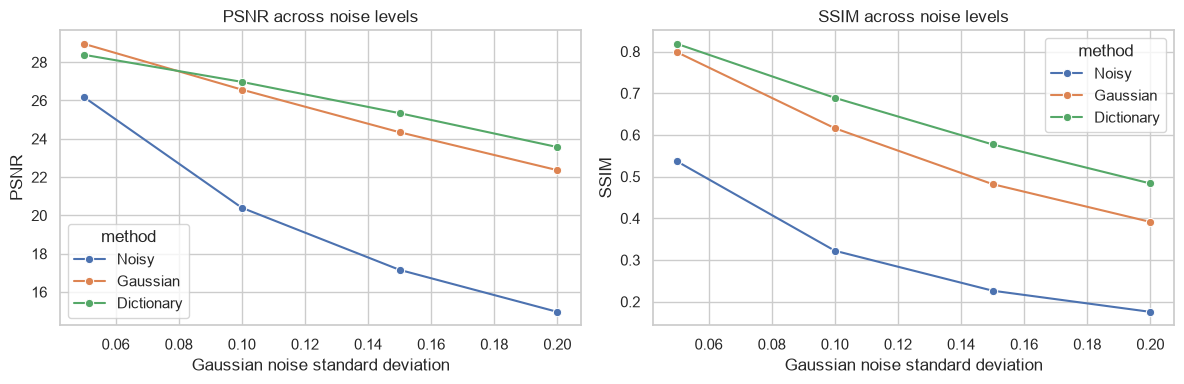

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(
    data=robustness_results, x="noise_sigma", y="PSNR",
    hue="method", marker="o", ax=axes[0]
)
axes[0].set_title("PSNR across noise levels")
axes[0].set_xlabel("Gaussian noise standard deviation")

sns.lineplot(
    data=robustness_results, x="noise_sigma", y="SSIM",
    hue="method", marker="o", ax=axes[1]
)
axes[1].set_title("SSIM across noise levels")
axes[1].set_xlabel("Gaussian noise standard deviation")

plt.tight_layout()
plt.show()

## Noise robustness 

- At the lowest noise level, Gaussian filtering achieved the highest PSNR at
  **28.9570 dB**, compared with **28.3860 dB** for dictionary learning.
- However, dictionary learning had slightly higher SSIM (**0.8183 versus
  0.7982**) and slightly lower MAE (**0.0231 versus 0.0233**) at this level.
- At noise sigma 0.10, dictionary learning surpassed Gaussian filtering on
  PSNR, SSIM, and MAE.
- The same advantage remained at noise levels 0.15 and 0.20.
- At the highest noise level, dictionary learning achieved PSNR =
  **23.5682 dB**, SSIM = **0.4836**, and MAE = **0.0512**. Gaussian filtering
  achieved 22.3619 dB, 0.3914, and 0.0596 respectively.
- Dictionary learning had its largest PSNR advantage over Gaussian filtering
  at noise sigma **0.20**, with an improvement of approximately **1.2063 dB**.
- The fixed validation settings were reasonably stable across moderate and
  heavy noise, but they were not optimal for low-noise PSNR.
- As noise increased, performance declined for every method because stronger
  corruption increasingly resembled real high-frequency image structure.

In [19]:
clean = camera_results["Clean"]
noisy = camera_results["Noisy"]
gaussian = camera_results["Gaussian"]
sparse = camera_results["Dictionary"]

squared_error = (clean - sparse) ** 2
local_mse = uniform_filter(squared_error, size=32)
worst_row, worst_column = np.unravel_index(np.argmax(local_mse), local_mse.shape)

crop_size = 40
half = crop_size // 2
row_start = int(np.clip(worst_row - half, 0, clean.shape[0] - crop_size))
column_start = int(np.clip(worst_column - half, 0, clean.shape[1] - crop_size))
crop = np.s_[row_start:row_start + crop_size,
             column_start:column_start + crop_size]

print(f"Worst region starts at row {row_start}, column {column_start}")
print(f"Dictionary crop MAE: {np.mean(np.abs(clean[crop] - sparse[crop])):.4f}")
print(f"Gaussian crop MAE: {np.mean(np.abs(clean[crop] - gaussian[crop])):.4f}")

Worst region starts at row 119, column 95
Dictionary crop MAE: 0.0598
Gaussian crop MAE: 0.0623


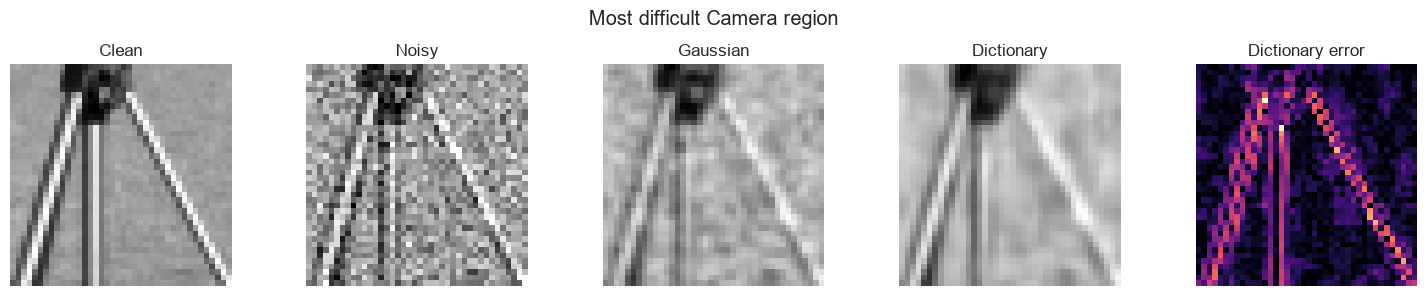

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

crop_images = {
    "Clean": clean[crop],
    "Noisy": noisy[crop],
    "Gaussian": gaussian[crop],
    "Dictionary": sparse[crop],
    "Dictionary error": np.abs(clean[crop] - sparse[crop])
}

for ax, (name, image) in zip(axes, crop_images.items()):
    ax.imshow(image, cmap="magma" if "error" in name else "gray")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Most difficult Camera region")
plt.tight_layout()
plt.show()

## Spatial error analysis

- The most difficult Camera region began near row **119** and column **95**.
- This crop contained the camera tripod, including several narrow vertical and
  diagonal legs against a textured grass background.
- Dictionary reconstruction produced crop MAE = **0.0598**, compared with
  **0.0623** for Gaussian filtering.
- Dictionary learning therefore remained slightly better in this difficult
  region, although both methods produced substantially more error here than
  their full-image averages.
- The model struggled because the crop combined thin, high-contrast lines,
  diagonal boundaries, intersections, and fine grass texture. Representing all
  of these details with only two 8 × 8 atoms per patch was difficult.
- The strongest errors were concentrated around the tripod edges, where small
  positional or intensity differences create large pixel-level errors.
- This example demonstrates that strong whole-image metrics can hide local
  failures around fine structural details.